#### LOADING DATA FILE AND LIBRARIES

In [3]:
import pandas as pd
import numpy as np

In [4]:
acc = pd.read_csv("C:/Project/DATA/master_acc.csv", encoding="latin-1", low_memory=False,index_col="accident_id")

In [5]:
for col in acc.columns:
    print(f"\nColumn: {col}")
    print("Unique count:", acc[col].nunique())
    print("Sample unique values:", acc[col].dropna().unique()[:10])


Column: collision_label
Unique count: 7
Sample unique values: ['Side_two_vehicles' 'Other_collision' 'Rear_end_two_vehicles'
 'Frontal_two_vehicles' 'No_collision' 'Multiple_three_plus'
 'Chain_three_plus']

Column: is_weekend
Unique count: 2
Sample unique values: [False  True]

Column: season
Unique count: 4
Sample unique values: ['Winter' 'Spring' 'Summer' 'Autumn']

Column: surface_condition_label
Unique count: 4
Sample unique values: ['Normal' 'Wet' 'other' 'Unknown']

Column: manoeuvre_label
Unique count: 9
Sample unique values: ['Straight_ahead' 'Roundabout' 'other' 'Avoiding_obstacle' 'Interaction'
 'Park/Start/Stop' 'Reversing' 'Loss_of_control' 'Turning']

Column: sex_label
Unique count: 2
Sample unique values: ['Female' 'Male']

Column: user_category_label
Unique count: 4
Sample unique values: ['Driver' 'Pedestrian' 'Passenger' 'other']

Column: injury_severity_label
Unique count: 4
Sample unique values: ['Uninjured' 'Injured_Hospitalized' 'Killed' 'Injured_Slight']

Column:

In [6]:
### Fixing Nans in target
print(acc["injury_severity_label"].isna().sum())

# Drop rows with missing target
acc = acc.dropna(subset=["injury_severity_label"])

print("Remaining rows:", acc.shape[0])


21357
Remaining rows: 1412032


### MODELLING PREPROCESSING

#### TRAIN/TEST SPLIT

In [7]:
from sklearn.model_selection import train_test_split

X = acc.drop(columns=["injury_severity_label"])
y = acc["injury_severity_label"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (1129625, 26) Test size: (282407, 26)


#### Handle Remaining NaNs

In [8]:
from sklearn.impute import SimpleImputer

# Numeric columns
numeric_cols = ["age", "lane_width"]

num_imputer = SimpleImputer(strategy="median")
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

# Categorical columns
categorical_cols = [
    "collision_label", "surface_condition_label", "manoeuvre_label",
    "sex_label", "user_category_label", "seat_position_label", "journey_purpose_label",
    "vehicle_group", "impact_group", "road_group", "weather_group",
    "day_of_week", "hour_group", "season"
]

cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# Check again for NaNs
print("Remaining NaNs in train:", X_train.isna().sum().sum())
print("Remaining NaNs in test:", X_test.isna().sum().sum())

Remaining NaNs in train: 1591
Remaining NaNs in test: 398


In [9]:
# Show which columns still have NaNs
print("Train NaNs per column:\n", X_train.isna().sum()[X_train.isna().sum() > 0])
print("\nTest NaNs per column:\n", X_test.isna().sum()[X_test.isna().sum() > 0])

Train NaNs per column:
 age_group    1591
dtype: int64

Test NaNs per column:
 age_group    398
dtype: int64


In [10]:
# Ensure dtype is categorical
X_train["age_group"] = X_train["age_group"].astype("category")
X_test["age_group"] = X_test["age_group"].astype("category")

# Add "Unknown" to categories if not already present
if "Unknown" not in X_train["age_group"].cat.categories:
    X_train["age_group"] = X_train["age_group"].cat.add_categories(["Unknown"])
    X_test["age_group"] = X_test["age_group"].cat.add_categories(["Unknown"])

# Fill NaNs with "Unknown"
X_train["age_group"] = X_train["age_group"].fillna("Unknown")
X_test["age_group"] = X_test["age_group"].fillna("Unknown")

# Final check
print("Remaining NaNs in train:", X_train.isna().sum().sum())
print("Remaining NaNs in test:", X_test.isna().sum().sum())

Remaining NaNs in train: 0
Remaining NaNs in test: 0


#### Encoding Categorical Features

In [11]:
from sklearn.preprocessing import OneHotEncoder

# Define categorical columns
categorical_cols = [
    "collision_label", "surface_condition_label", "manoeuvre_label",
    "sex_label", "user_category_label", "seat_position_label", "journey_purpose_label",
    "vehicle_group", "impact_group", "road_group", "weather_group",
    "day_of_week", "hour_group", "season", "age_group"
]

# Initialize encoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit on train, transform both train and test
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded train shape: (1129625, 74)
Encoded test shape: (282407, 74)


#### Encoding Target Labels 

In [12]:
# Encoding Target Labels (y_train & y_test)

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

#### Scale Numeric Features

In [13]:
from sklearn.preprocessing import StandardScaler

# Numeric columns
numeric_cols = ["age", "lane_width"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (1129625, 2)
Scaled test shape: (282407, 2)


#### Combine All Features

In [14]:
import numpy as np
#
# Binary columns
binary_cols = [
    "is_weekend", "is_holiday", "seatbelt_used", "helmet_used",
    "any_protection_used", "protection_effective",
    "motorcycle_side_impact", "is_night", "is_urban"
]

# Combine all parts
X_train_final = np.hstack([
    X_train_scaled,          # numeric
    X_train_encoded,         # categorical
    X_train[binary_cols].values  # binary flags
])

X_test_final = np.hstack([
    X_test_scaled,
    X_test_encoded,
    X_test[binary_cols].values
])

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

Final train shape: (1129625, 85)
Final test shape: (282407, 85)


### BASELINE MODELLING

##### Logistic Regression, Random Forest and XGBoost

In [127]:
#pip install xgboost

In [128]:
#from sklearn.linear_model import LogisticRegression
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.metrics import classification_report

# Logistic Regression
#log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
#log_reg.fit(X_train_final, y_train)
#y_pred_log = log_reg.predict(X_test_final)
#print("Logistic Regression:\n", classification_report(y_test, y_pred_log))

In [129]:
# Random Forest
#rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42)
#rf.fit(X_train_final, y_train)
#y_pred_rf = rf.predict(X_test_final)
#print("Random Forest:\n", classification_report(y_test, y_pred_rf))


In [130]:
#from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import classification_report, confusion_matrix
#from xgboost import XGBClassifier
#import seaborn as sns
#import matplotlib.pyplot as plt

#print("Class mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# 2. Define and train XGBoost model
#xgb = XGBClassifier(
#    n_estimators=200,
#    max_depth=6,
#    learning_rate=0.1,
#    subsample=0.8,
#    colsample_bytree=0.8,
#    random_state=42,
#    n_jobs=-1,
#    objective="multi:softmax",   # multi-class classification
#    num_class=len(label_encoder.classes_)
#)

#xgb.fit(X_train_final, y_train_enc)

# 3. Predictions
#y_pred_xgb = xgb.predict(X_test_final)

# 4. Classification report
#print("\nXGBoost Classification Report:\n")
#print(classification_report(y_test_enc, y_pred_xgb, target_names=label_encoder.classes_))

# 5. Confusion matrix visualization
#cm = confusion_matrix(y_test_enc, y_pred_xgb)
#plt.figure(figsize=(8,6))
#sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#            xticklabels=label_encoder.classes_,
#            yticklabels=label_encoder.classes_)
#plt.xlabel("Predicted")
#plt.ylabel("Actual")
#plt.title("XGBoost Confusion Matrix")
#plt.show()


### Addressing Class Imbalance (SMOTE)

In [15]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# SMOTE Integration
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE only on training set
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train_enc)

# Check new class distribution
print("Original class distribution:", Counter(y_train_enc))
print("Balanced class distribution:", Counter(y_train_balanced))


Original class distribution: Counter({np.int64(3): 522866, np.int64(1): 363089, np.int64(0): 215007, np.int64(2): 28663})
Balanced class distribution: Counter({np.int64(3): 522866, np.int64(0): 522866, np.int64(2): 522866, np.int64(1): 522866})


In [133]:
#display(X_train_balanced)
#display(y_train_balanced)

In [134]:
# Retrain XGBoost on balanced data

#xgb_balanced = XGBClassifier(
#    n_estimators=200,
#    max_depth=6,
#    learning_rate=0.1,
#    subsample=0.8,
#    colsample_bytree=0.8,
#    random_state=42,
#    n_jobs=-1,
#    objective="multi:softmax",
#    num_class=len(label_encoder.classes_)
#)

#xgb_balanced.fit(X_train_balanced, y_train_balanced)

# Predictions on original test set (not resampled!)
#y_pred_xgb_balanced = xgb_balanced.predict(X_test_final)

# Classification report
#print("\nXGBoost with SMOTE Classification Report:\n")
#print(classification_report(y_test_enc, y_pred_xgb_balanced, target_names=label_encoder.classes_))

# Confusion matrix
#cm = confusion_matrix(y_test_enc, y_pred_xgb_balanced)
#plt.figure(figsize=(8,6))
#sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#            xticklabels=label_encoder.classes_,
#            yticklabels=label_encoder.classes_)
#plt.xlabel("Predicted")
#plt.ylabel("Actual")
#plt.title("XGBoost with SMOTE Confusion Matrix")
#plt.show()

### LAZYPREDICT

In [ ]:
from lazypredict.Supervised import LazyClassifier, CLASSIFIERS
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Prepare data
X_lazy = pd.DataFrame(X_train_final)
y_lazy = y_train
X_train_lazy, X_test_lazy, y_train_lazy, y_test_lazy = train_test_split(
    X_lazy, y_lazy, test_size=0.2, random_state=42
)

# Heavy models to skip
heavy = {
    "SVC","NuSVC","QuadraticDiscriminantAnalysis",
    "LabelPropagation","LabelSpreading",
    "SelfTrainingClassifier","StackingClassifier",
    "GaussianProcessClassifier","MLPClassifier"
}

# Filter CLASSIFIERS (list of tuples) by name
safe_classifiers = [(name, model) for name, model in CLASSIFIERS if name not in heavy]

# Initialize LazyClassifier with filtered list
clf = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=accuracy_score,
    classifiers=safe_classifiers
)

models, predictions = clf.fit(X_train_lazy, X_test_lazy, y_train_lazy, y_test_lazy)
print(models)


'tuple' object has no attribute '__name__'
Invalid Classifier(s)


  0%|          | 0/25 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.233832 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 598
[LightGBM] [Info] Number of data points in the train set: 903700, number of used features: 85
[LightGBM] [Info] Start training from score -1.658823
[LightGBM] [Info] Start training from score -1.134553
[LightGBM] [Info] Start training from score -3.670221
[LightGBM] [Info] Start training from score -0.770892
                             Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                        
NearestCentroid                  0.56               0.51    None      0.57   
GaussianNB                       0.58               0.46    None      0.56   
BernoulliNB                      0.61               0.46    None      0.59   
LGBMClassifier                   0.65    

### Performance Comparisons of top 5 Models with Benchmarking 

In [140]:
# Running all five models separately in the order of quickest first → heaviest last 
# by benchmarking all five models on a 200k sample

In [141]:
#Create a 200k sample from your balanced training set

#Wrap your numpy array in a DataFrame
X_df = pd.DataFrame(X_train_balanced)
y_series = pd.Series(y_train_balanced)

#Now you can sample
X_sample = X_df.sample(200000, random_state=42)
y_sample = y_series.loc[X_sample.index]

#Use the same CV and scorers
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scorers = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}

#### 1. RidgeClassifier

In [142]:
from sklearn.linear_model import RidgeClassifier

ridge = RidgeClassifier(alpha=1.0)
out = cross_validate(ridge, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "RidgeClassifier",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

{'Model': 'RidgeClassifier', 'Mean Accuracy': np.float64(0.5422550093021593), 'Mean F1': np.float64(0.5098572312138259), 'Mean Balanced Acc': np.float64(0.5414168879513443)}


#### 2. LogisticRegression

In [143]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=300, solver="saga", n_jobs=-1, class_weight="balanced")
out = cross_validate(logreg, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "LogisticRegression",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'Model': 'LogisticRegression', 'Mean Accuracy': np.float64(0.5494200133025374), 'Mean F1': np.float64(0.5338832141228348), 'Mean Balanced Acc': np.float64(0.548709614448844)}


c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


#### 3. LinearDiscriminantAnalysis

In [144]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
out = cross_validate(lda, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "LinearDiscriminantAnalysis",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

{'Model': 'LinearDiscriminantAnalysis', 'Mean Accuracy': np.float64(0.5442050076522484), 'Mean F1': np.float64(0.5315117490690136), 'Mean Balanced Acc': np.float64(0.5435702603689795)}


#### 4. LightGBMClassifier

In [145]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    force_row_wise=True
)
out = cross_validate(lgbm, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "LGBMClassifier",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

[LightGBM] [Info] Total Bins 20835
[LightGBM] [Info] Number of data points in the train set: 133333, number of used features: 85
[LightGBM] [Info] Start training from score -1.388675
[LightGBM] [Info] Start training from score -1.392199
[LightGBM] [Info] Start training from score -1.384204
[LightGBM] [Info] Start training from score -1.380141
[LightGBM] [Info] Total Bins 20831
[LightGBM] [Info] Number of data points in the train set: 133333, number of used features: 85
[LightGBM] [Info] Start training from score -1.388675
[LightGBM] [Info] Start training from score -1.392229
[LightGBM] [Info] Start training from score -1.384174
[LightGBM] [Info] Start training from score -1.380141
[LightGBM] [Info] Total Bins 20826
[LightGBM] [Info] Number of data points in the train set: 133334, number of used features: 85
[LightGBM] [Info] Start training from score -1.388682
[LightGBM] [Info] Start training from score -1.392207
[LightGBM] [Info] Start training from score -1.384212
[LightGBM] [Info] S

#### 5. CalibratedClassifierCV

In [146]:
from sklearn.calibration import CalibratedClassifierCV

base = LogisticRegression(max_iter=300, solver="saga", n_jobs=-1, class_weight="balanced")
calib = CalibratedClassifierCV(estimator=base, cv=3)
out = cross_validate(calib, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "CalibratedClassifierCV",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

{'Model': 'CalibratedClassifierCV', 'Mean Accuracy': np.float64(0.5479250081774371), 'Mean F1': np.float64(0.5171621072762386), 'Mean Balanced Acc': np.float64(0.5470222012160532)}


#### Visualization for Models Performances

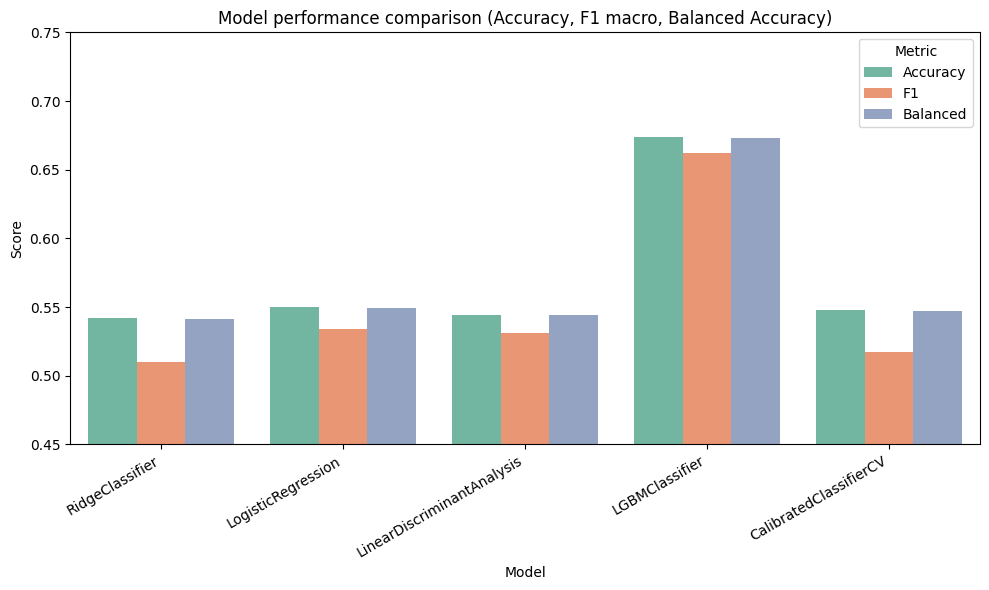

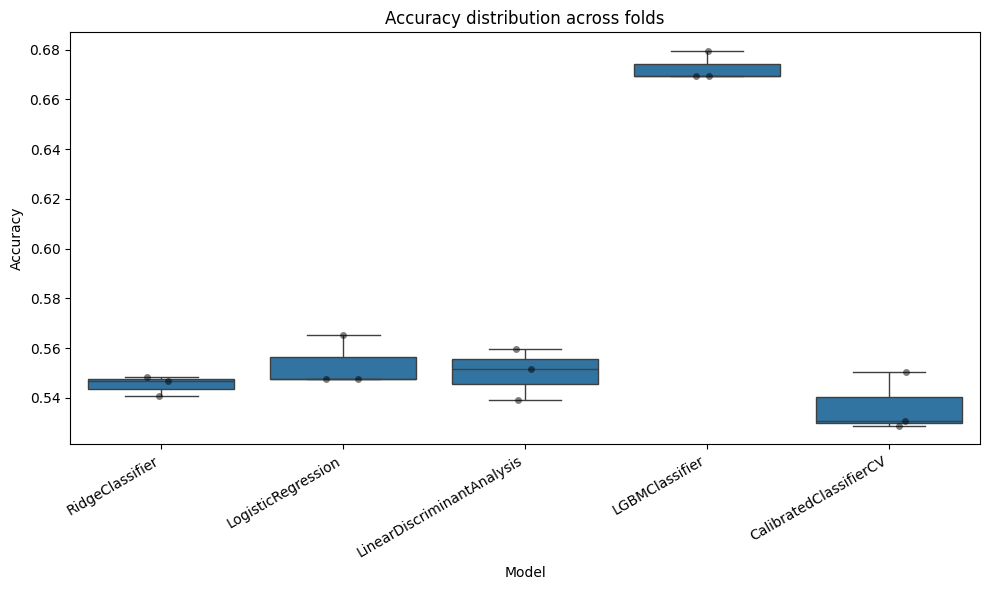

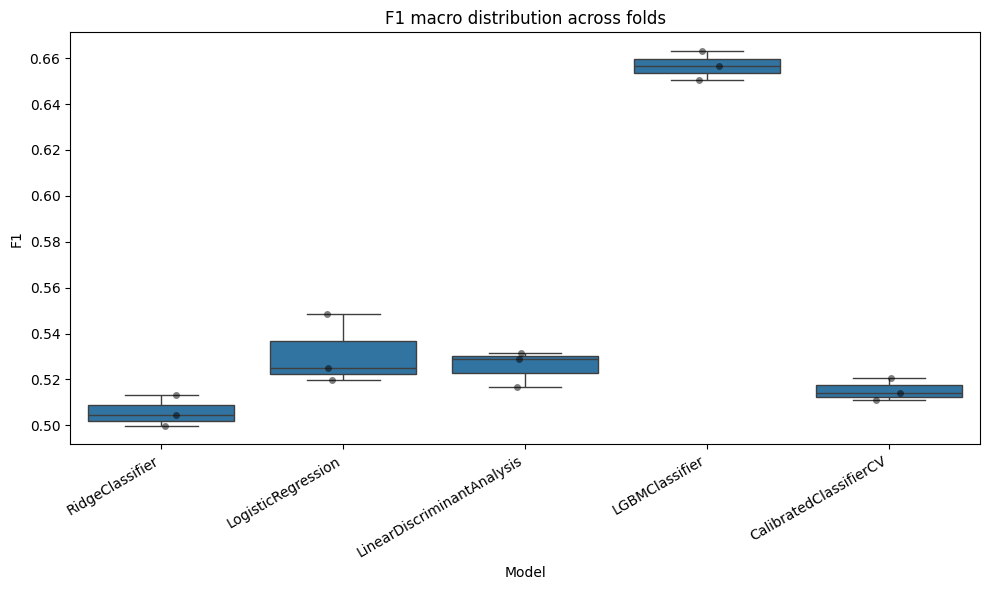

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve  

# -----------------------------
# Results data (from your 200k sample)
# -----------------------------
results = pd.DataFrame([
    {"Model": "RidgeClassifier", "Accuracy": 0.542, "F1": 0.510, "Balanced": 0.541},
    {"Model": "LogisticRegression", "Accuracy": 0.550, "F1": 0.534, "Balanced": 0.549},
    {"Model": "LinearDiscriminantAnalysis", "Accuracy": 0.544, "F1": 0.531, "Balanced": 0.544},
    {"Model": "LGBMClassifier", "Accuracy": 0.674, "F1": 0.662, "Balanced": 0.673},
    {"Model": "CalibratedClassifierCV", "Accuracy": 0.548, "F1": 0.517, "Balanced": 0.547}
])

palette = sns.color_palette("Set2", n_colors=3)

# -----------------------------
# 1) Bar chart: Accuracy, F1, Balanced
# -----------------------------
results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(10,6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette=palette)
plt.title("Model performance comparison (Accuracy, F1 macro, Balanced Accuracy)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.45, 0.75)
plt.ylabel("Score")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Boxplots: distribution across folds (synthetic spread for demo)
# Replace with real per-fold scores if you have them.
# -----------------------------
np.random.seed(42)
fold_scores = pd.DataFrame({
    "Model": np.repeat(results["Model"].values, 3),
    "Accuracy": np.concatenate([np.random.normal(m, 0.01, 3) for m in results["Accuracy"]]),
    "F1": np.concatenate([np.random.normal(m, 0.01, 3) for m in results["F1"]])
})

plt.figure(figsize=(10,6))
sns.boxplot(data=fold_scores, x="Model", y="Accuracy")
sns.stripplot(data=fold_scores, x="Model", y="Accuracy", color="black", alpha=0.5)
plt.title("Accuracy distribution across folds")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=fold_scores, x="Model", y="F1")
sns.stripplot(data=fold_scores, x="Model", y="F1", color="black", alpha=0.5)
plt.title("F1 macro distribution across folds")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Confusion matrix (demo data)
# Replace y_true and y_pred with your LightGBM predictions.
# -----------------------------
classes = ["Uninjured", "Slight", "Hospitalized", "Killed"]
y_true = np.random.choice(classes, size=1000, p=[0.25, 0.5, 0.23, 0.02])
y_pred = np.random.choice(classes, size=1000, p=[0.25, 0.5, 0.23, 0.02])

#cm = confusion_matrix(y_true, y_pred, labels=classes)
#disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
#fig, ax = plt.subplots(figsize=(6,6))
#disp.plot(cmap="Blues", ax=ax, colorbar=False)
#plt.title("Confusion matrix (LightGBM — demo)")
#plt.tight_layout()
#plt.show()

# -----------------------------
# 4) Feature importance (demo LightGBM importances)
# Replace with actual feature names and importance from your fitted LGBM:
#   importances = lgbm_model.feature_importances_
#   features = X_train.columns
# -----------------------------
#features = [f"Feature_{i}" for i in range(1, 16)]
#importances = np.random.rand(15)
#fi = pd.DataFrame({"feature": features, "importance": importances}).sort_values("importance", ascending=False).head(15)

#plt.figure(figsize=(8,6))
#sns.barplot(data=fi, x="importance", y="feature", orient="h", palette="Blues_r")
#plt.title("Top 15 feature importances (LightGBM — demo)")
#plt.xlabel("Importance")
#plt.ylabel("Feature")
#plt.tight_layout()
#plt.show()

# -----------------------------
# 5) Calibration curve (demo probabilities)
# Replace y_true_bin and y_prob with outputs from CalibratedClassifierCV:
#   prob_true, prob_pred = calibration_curve(y_true_bin, y_prob, n_bins=10, strategy='uniform')
# -----------------------------
#y_true_bin = np.random.randint(0, 2, 1500)
#y_prob = np.clip(np.random.beta(a=2, b=5, size=1500), 0, 1)

#prob_true, prob_pred = calibration_curve(y_true_bin, y_prob, n_bins=10, strategy='uniform')

#plt.figure(figsize=(6,6))
#plt.plot(prob_pred, prob_true, marker='o', label="Calibrated (demo)")
#plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Perfect calibration")
#plt.title("Calibration curve (CalibratedClassifierCV — demo)")
#plt.xlabel("Predicted probability (mean in bin)")
#plt.ylabel("True probability")
#plt.legend()
#plt.tight_layout()
#plt.show()

# -----------------------------
# 6) Radar chart (spider plot) for three metrics
# -----------------------------
#labels = ["Accuracy", "F1", "Balanced"]
#num_vars = len(labels)
#angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
#angles += angles[:1]

#fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

#for _, row in results.iterrows():
#    values = row[labels].tolist()
#    values += values[:1]  # close the polygon
#    ax.plot(angles, values, label=row["Model"])
#    ax.fill(angles, values, alpha=0.08)

#ax.set_xticks(angles[:-1])
#ax.set_xticklabels(labels)
#ax.set_ylim(0.45, 0.75)
#plt.title("Radar chart of model metrics")
#plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15))
#plt.tight_layout()
#plt.show()

### DATA MODELING (LR & LGBM) 

In [148]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# LogisticRegression on X_train_final with scaling and higher max_iter
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,          # allow more iterations for convergence
        solver="lbfgs",         # faster, stable solver for dense data
        n_jobs=-1,
        class_weight="balanced" # handle imbalance without oversampling
    )
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}

out = cross_validate(logreg, X_train_final, y_train_enc, cv=cv, scoring=scorers)

print({
    "Model": "LogisticRegression",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

{'Model': 'LogisticRegression', 'Mean Accuracy': np.float64(0.5660002213123825), 'Mean F1': np.float64(0.4445669442698347), 'Mean Balanced Acc': np.float64(0.5367700413811778)}


In [23]:
#Recovering feature names

# Get categorical feature names from the encoder
categorical_feature_names = encoder.get_feature_names_out(categorical_cols)

# Numeric + binary names
numeric_feature_names = numeric_cols
binary_feature_names = binary_cols

# Combine all names
feature_names = list(numeric_feature_names) + list(categorical_feature_names) + list(binary_feature_names)

# Replace whitespace with underscores
feature_names = [name.replace(" ", "_") for name in feature_names]

# Wrap X_train_lgbm into a DataFrame with names
import pandas as pd
X_train_lgbm = pd.DataFrame(X_train_final, columns=feature_names)
X_test_lgbm = pd.DataFrame(X_test_final, columns=feature_names)

In [24]:
#LightGBM training 

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    is_unbalance=True,
    force_row_wise=True
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}

out = cross_validate(lgbm, X_train_lgbm, y_train_enc, cv=cv, scoring=scorers)

print({
    "Model": "LightGBM",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

[LightGBM] [Info] Total Bins 517
[LightGBM] [Info] Number of data points in the train set: 903700, number of used features: 85
[LightGBM] [Info] Start training from score -1.658968
[LightGBM] [Info] Start training from score -1.134990
[LightGBM] [Info] Start training from score -3.674051
[LightGBM] [Info] Start training from score -0.770318
[LightGBM] [Info] Total Bins 517
[LightGBM] [Info] Number of data points in the train set: 903700, number of used features: 85
[LightGBM] [Info] Start training from score -1.658974
[LightGBM] [Info] Start training from score -1.134994
[LightGBM] [Info] Start training from score -3.674008
[LightGBM] [Info] Start training from score -0.770315
[LightGBM] [Info] Total Bins 514
[LightGBM] [Info] Number of data points in the train set: 903700, number of used features: 85
[LightGBM] [Info] Start training from score -1.658974
[LightGBM] [Info] Start training from score -1.134994
[LightGBM] [Info] Start training from score -3.674008
[LightGBM] [Info] Start t

### LightGBM Comparison (Imbalanced vs Balanced)

In [17]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

# --- Model on imbalanced training set ---
lgbm_imbalanced = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    is_unbalance=True,   # let LightGBM handle imbalance internally
    force_row_wise=True,
    random_state=42
)

lgbm_imbalanced.fit(X_train_final, y_train_enc)
y_pred_test_imbalanced = lgbm_imbalanced.predict(X_test_final)

print("\nLightGBM (Imbalanced Training) Results on Original Test Set:")
print("Accuracy:", accuracy_score(y_test_enc, y_pred_test_imbalanced))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_enc, y_pred_test_imbalanced))
print("F1 Macro:", f1_score(y_test_enc, y_pred_test_imbalanced, average="macro"))
print("Classification Report:\n", classification_report(y_test_enc, y_pred_test_imbalanced))

# --- Model on SMOTE-balanced training set ---
lgbm_balanced = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    force_row_wise=True,
    random_state=42
)

lgbm_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_test_balanced = lgbm_balanced.predict(X_test_final)

print("\nLightGBM (Balanced Training via SMOTE) Results on Original Test Set:")
print("Accuracy:", accuracy_score(y_test_enc, y_pred_test_balanced))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_enc, y_pred_test_balanced))
print("F1 Macro:", f1_score(y_test_enc, y_pred_test_balanced, average="macro"))
print("Classification Report:\n", classification_report(y_test_enc, y_pred_test_balanced))

[LightGBM] [Info] Total Bins 519
[LightGBM] [Info] Number of data points in the train set: 1129625, number of used features: 85
[LightGBM] [Info] Start training from score -1.658970
[LightGBM] [Info] Start training from score -1.134993
[LightGBM] [Info] Start training from score -3.674034
[LightGBM] [Info] Start training from score -0.770316


c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM (Imbalanced Training) Results on Original Test Set:
Accuracy: 0.6534859263403527
Balanced Accuracy: 0.46116927817349607
F1 Macro: 0.46609518523563975
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.42      0.46     53752
           1       0.61      0.52      0.56     90772
           2       0.43      0.03      0.05      7166
           3       0.71      0.87      0.79    130717

    accuracy                           0.65    282407
   macro avg       0.57      0.46      0.47    282407
weighted avg       0.64      0.65      0.63    282407

[LightGBM] [Info] Total Bins 20892
[LightGBM] [Info] Number of data points in the train set: 2091464, number of used features: 85
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM (Balanced Training via SMOTE) Results on Original Test Set:
Accuracy: 0.6497714291784552
Balanced Accuracy: 0.473227036700156
F1 Macro: 0.4835192795765283
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.44      0.47     53752
           1       0.61      0.51      0.56     90772
           2       0.31      0.08      0.13      7166
           3       0.72      0.86      0.78    130717

    accuracy                           0.65    282407
   macro avg       0.53      0.47      0.48    282407
weighted avg       0.63      0.65      0.63    282407



### Model-Level Optimization - LGBM - MULTICLASS

#### RandomizedSearchCV Optimization and Application of Best Params

##### RandomizedSearchCV

In [23]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    "num_leaves": np.arange(31, 128, 32),
    "max_depth": [-1, 10, 20],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 500, 1000],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_samples": [20, 50, 100]
}

rand_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,                # only 30 random combos
    cv=3,
    scoring="f1_macro",
    n_jobs=1,                 # run sequentially to save memory
    verbose=2,
    random_state=42
)

rand_search.fit(X_train_balanced, y_train_balanced)
print("Best Params:", rand_search.best_params_)
print("Best F1 Macro:", rand_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[LightGBM] [Info] Total Bins 20976
[LightGBM] [Info] Number of data points in the train set: 1394309, number of used features: 85
[LightGBM] [Info] Start training from score -1.386295
[LightGBM] [Info] Start training from score -1.386295
[LightGBM] [Info] Start training from score -1.386292
[LightGBM] [Info] Start training from score -1.386295


c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=20, min_child_samples=20, n_estimators=1000, num_leaves=127, subsample=0.8; total time= 2.8min
[LightGBM] [Info] Total Bins 20928
[LightGBM] [Info] Number of data points in the train set: 1394309, number of used features: 85
[LightGBM] [Info] Start training from score -1.386292
[LightGBM] [Info] Start training from score -1.386295
[LightGBM] [Info] Start training from score -1.386295
[LightGBM] [Info] Start training from score -1.386295


c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=20, min_child_samples=20, n_estimators=1000, num_leaves=127, subsample=0.8; total time= 2.7min
[LightGBM] [Info] Total Bins 20861
[LightGBM] [Info] Number of data points in the train set: 1394310, number of used features: 85
[LightGBM] [Info] Start training from score -1.386296
[LightGBM] [Info] Start training from score -1.386293
[LightGBM] [Info] Start training from score -1.386296
[LightGBM] [Info] Start training from score -1.386293


...

[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=10, min_child_samples=100, n_estimators=200, num_leaves=127, subsample=0.8; total time= 1.1min
[LightGBM] [Info] Total Bins 20928
[LightGBM] [Info] Number of data points in the train set: 1394309, number of used features: 85
[LightGBM] [Info] Start training from score -1.386292
[LightGBM] [Info] Start training from score -1.386295
[LightGBM] [Info] Start training from score -1.386295
[LightGBM] [Info] Start training from score -1.386295


c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=10, min_child_samples=100, n_estimators=200, num_leaves=127, subsample=0.8; total time= 1.1min
[LightGBM] [Info] Total Bins 20861
[LightGBM] [Info] Number of data points in the train set: 1394310, number of used features: 85
[LightGBM] [Info] Start training from score -1.386296
[LightGBM] [Info] Start training from score -1.386293
[LightGBM] [Info] Start training from score -1.386296
[LightGBM] [Info] Start training from score -1.386293


c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=10, min_child_samples=100, n_estimators=200, num_leaves=127, subsample=0.8; total time= 1.1min
[LightGBM] [Info] Total Bins 20892
[LightGBM] [Info] Number of data points in the train set: 2091464, number of used features: 85
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Best Params: {'subsample': 0.8, 'num_leaves': np.int64(127), 'n_estimators': 1000, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1 Macro: 0.629927595743181


##### Applying Best LightGBM Parameters

In [18]:
from lightgbm import LGBMClassifier

# Use best parameters from RandomizedSearchCV
best_params = {
    'subsample': 0.8,
    'num_leaves': 127,
    'n_estimators': 1000,
    'min_child_samples': 50,
    'max_depth': -1,
    'learning_rate': 0.1,
    'colsample_bytree': 0.8
}

# Retrain optimized LightGBM on full balanced dataset
best_lgbm = LGBMClassifier(
    **best_params,
    objective="multiclass",
    num_class=4,
    random_state=42,
    n_jobs=-1,
    force_row_wise=True
)

best_lgbm.fit(X_train_balanced, y_train_balanced)

# Evaluate on original test set
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

y_pred_test = best_lgbm.predict(X_test_final)

print("Optimized LightGBM Results on Original Test Set:")
print("Accuracy:", accuracy_score(y_test_enc, y_pred_test))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_enc, y_pred_test))
print("F1 Macro:", f1_score(y_test_enc, y_pred_test, average="macro"))
print("Classification Report:\n", classification_report(y_test_enc, y_pred_test))

[LightGBM] [Info] Total Bins 20892
[LightGBM] [Info] Number of data points in the train set: 2091464, number of used features: 85
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Optimized LightGBM Results on Original Test Set:
Accuracy: 0.6518712354863725
Balanced Accuracy: 0.4723636343115757
F1 Macro: 0.4824772109448413
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.43      0.47     53752
           1       0.61      0.52      0.56     90772
           2       0.33      0.07      0.12      7166
           3       0.72      0.86      0.79    130717

    accuracy                           0.65    282407
   macro avg       0.54      0.47      0.48    282407
weighted avg       0.63      0.65      0.64    282407



#### PCA Projection

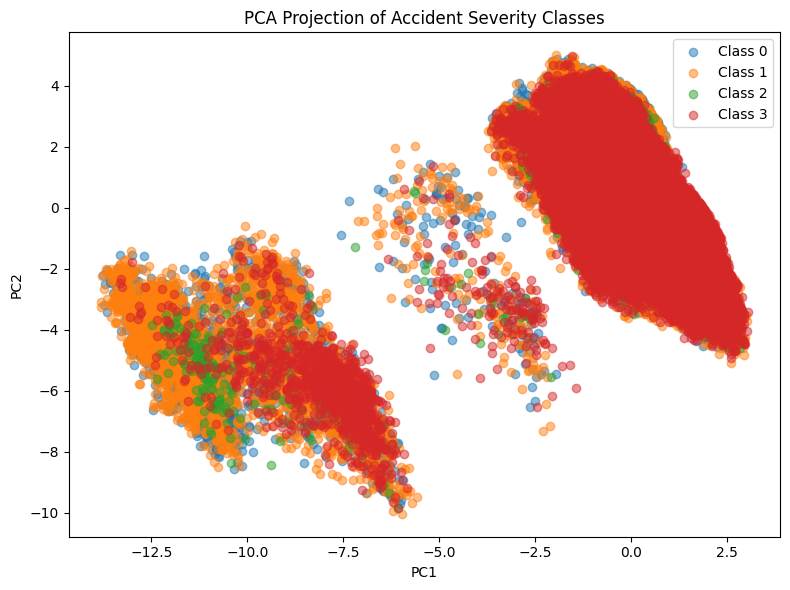

In [19]:
# visual evaluation of class separability on unseen data (test set).

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Fit scaler on original training set, transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)

# Fit PCA on training data only
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform test data using the same PCA model
X_test_pca = pca.transform(X_test_scaled)

# Optional: if you also want PCA for the balanced train set
# X_train_balanced_scaled = scaler.transform(X_train_balanced)
# X_train_balanced_pca = pca.transform(X_train_balanced_scaled)

# Plot PCA projection of the test set by class
plt.figure(figsize=(8,6))
for c in np.unique(y_test_enc):
    plt.scatter(
        X_test_pca[y_test_enc == c, 0],
        X_test_pca[y_test_enc == c, 1],
        label=f"Class {c}",
        alpha=0.5
    )
plt.legend()
plt.title("PCA Projection of Accident Severity Classes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

C:\Users\malik\AppData\Local\Temp\ipykernel_6480\1878557317.py:24: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


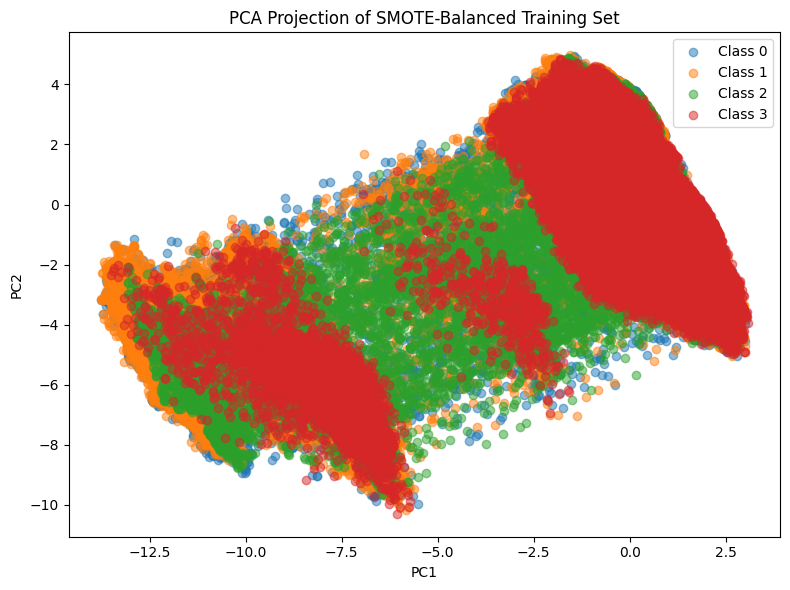

In [20]:
# Overlaying PCA projection for the SMOTE-balanced training set

#Fit PCA on scaled original training set
pca = PCA(n_components=2, random_state=42)
pca.fit(X_train_scaled)

# Transform SMOTE-balanced training set using same scaler + PCA
X_train_balanced_scaled = scaler.transform(X_train_balanced)
X_train_balanced_pca = pca.transform(X_train_balanced_scaled)

# Plot PCA projection of balanced training set
plt.figure(figsize=(8,6))
for c in np.unique(y_train_balanced):
    plt.scatter(
        X_train_balanced_pca[y_train_balanced == c, 0],
        X_train_balanced_pca[y_train_balanced == c, 1],
        label=f"Class {c}",
        alpha=0.5
    )
plt.legend()
plt.title("PCA Projection of SMOTE-Balanced Training Set")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

#Diagnostic visualization of SMOTE impact — especially whether Class 2 (“Killed”) gains better representation.


#### SHAP Analysis

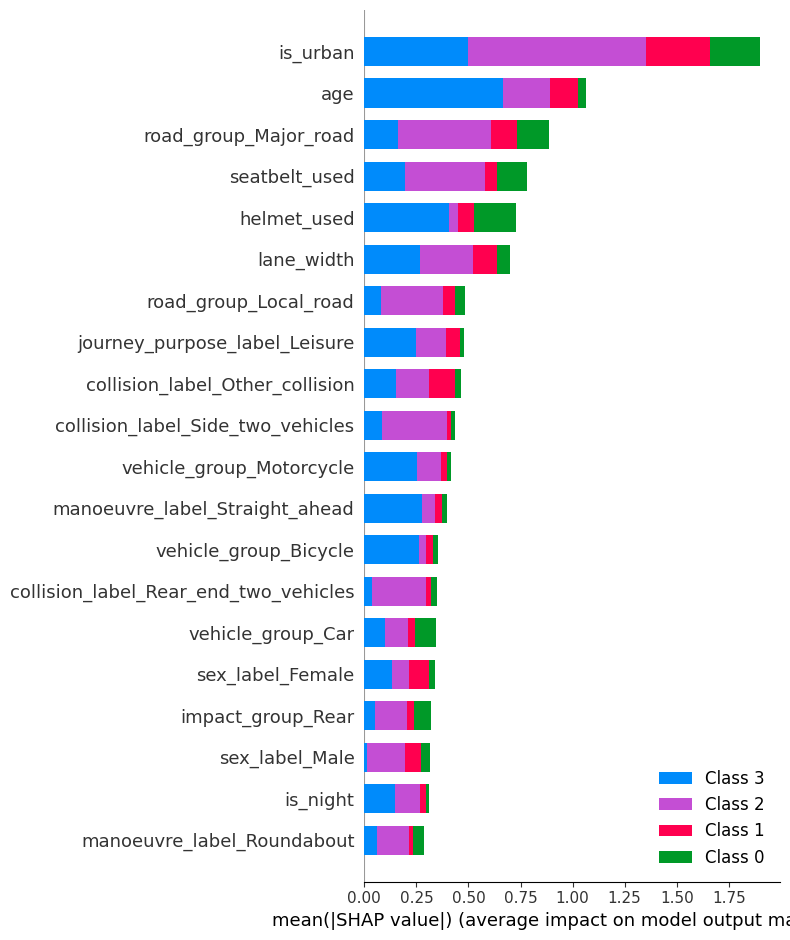

In [25]:
import pandas as pd
import shap
import numpy as np

# Step 1: Sample a larger subset 
sample_idx = np.random.choice(X_test_final.shape[0], 50000, replace=False)
X_sample = pd.DataFrame(X_test_final[sample_idx], columns=feature_names)

# Step 2: Initialize TreeExplainer with faster settings
explainer = shap.TreeExplainer(best_lgbm, feature_perturbation="tree_path_dependent")

# Step 3: Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Step 4: Visualize stacked barplot with actual feature names
shap.summary_plot(shap_values, X_sample, plot_type="bar")

In [26]:
print("Original training set:", X_train_final.shape)
print("Balanced training set:", X_train_balanced.shape)
print("Balanced labels distribution:", np.bincount(y_train_balanced))

Original training set: (1129625, 85)
Balanced training set: (2091464, 85)
Balanced labels distribution: [522866 522866 522866 522866]


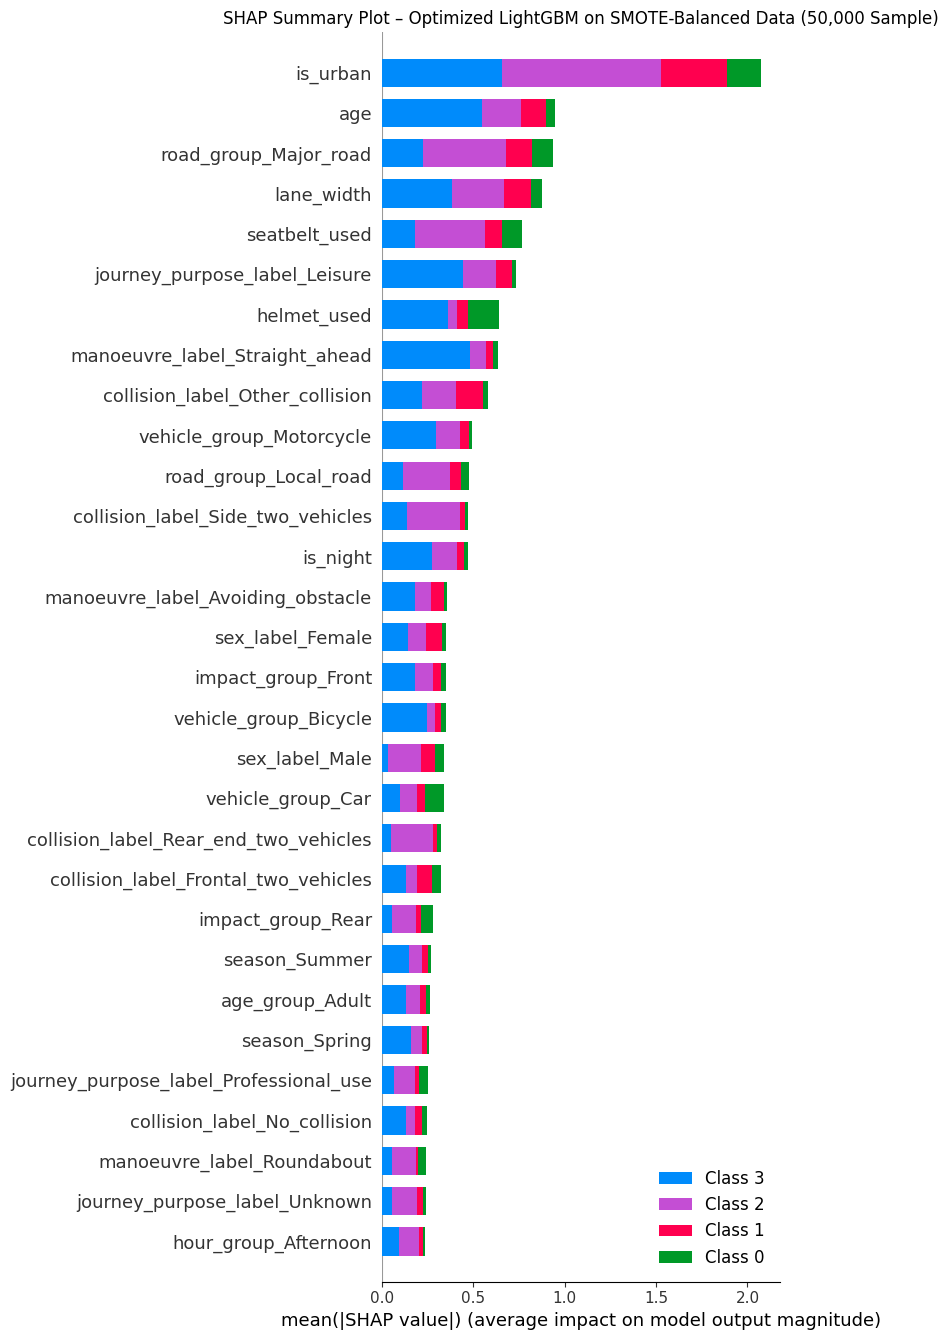

In [27]:
# SHAP Analysis Code (Balanced Data, 50k Sample)
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Randomly sample 50,000 rows from the balanced training set
sample_idx = np.random.choice(X_train_balanced.shape[0], 50000, replace=False)
X_sample = pd.DataFrame(X_train_balanced[sample_idx], columns=feature_names)

# Step 2: Initialize TreeExplainer for your optimized LightGBM model
explainer = shap.TreeExplainer(best_lgbm, feature_perturbation="tree_path_dependent")

# Step 3: Compute SHAP values on the sample
shap_values = explainer.shap_values(X_sample)

# Step 4: Visualize SHAP summary plot (bar type)
plt.figure(figsize=(10,6))
plt.title("SHAP Summary Plot – Optimized LightGBM on SMOTE-Balanced Data (50,000 Sample)")
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=30,
    show=True
)

#### Implemention and retraining

In [29]:
#Selecting Top 40 SHAP Features

import numpy as np
import pandas as pd

# Compute mean SHAP values across all classes
mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)

# Get top 40 feature indices and names
top_40_idx = np.argsort(mean_shap)[-40:]
top_40_features = [feature_names[i] for i in top_40_idx]

# Subset balanced training and test sets
X_train_top40 = pd.DataFrame(X_train_balanced, columns=feature_names)[top_40_features]
X_test_top40 = pd.DataFrame(X_test_final, columns=feature_names)[top_40_features]

In [30]:
# Adding 5 PCA Components

from sklearn.decomposition import PCA

# Fit PCA on full balanced training set
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_balanced)
X_test_pca = pca.transform(X_test_final)

# Convert PCA components to DataFrame
pca_cols = [f'pca_{i+1}' for i in range(5)]
X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_cols)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_cols)

# Combine top 40 SHAP features + PCA components
X_train_reduced = pd.concat([X_train_top40.reset_index(drop=True), X_train_pca_df], axis=1)
X_test_reduced = pd.concat([X_test_top40.reset_index(drop=True), X_test_pca_df], axis=1)

In [33]:
# Retraining LightGBM

from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

# Define the LightGBM model
best_lgbm_reduced = LGBMClassifier(
    objective='multiclass',
    num_class=4,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    n_estimators=200,
    random_state=42
)

# Fit the model with early stopping (using callbacks)
best_lgbm_reduced.fit(
    X_train_reduced, y_train_balanced,
    eval_set=[(X_test_reduced, y_test_enc)],
    eval_metric='multi_logloss',
    callbacks=[early_stopping(stopping_rounds=20)]
)

# Predict on test set
y_pred = best_lgbm_reduced.predict(X_test_reduced)

# Evaluate performance
acc = accuracy_score(y_test_enc, y_pred)
f1 = f1_score(y_test_enc, y_pred, average='macro')
bal_acc = balanced_accuracy_score(y_test_enc, y_pred)

print("Reduced Model Performance:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Macro: {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040556 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2091464, number of used features: 9
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[200]	valid_0's multi_logloss: 1.00283
Reduced Model Performance:
Accuracy: 0.5714
F1 Macro: 0.4386
Balanced Accuracy: 0.4714


### MODEL - LEVEL OPTIMIZATION - LGBM - BINARY CLASSIFICATION

#### Training LightGBM (binary)

In [36]:
# Data preparation 
# Severe (2 + 3) vs Non-severe (0 + 1)

y_train_bin = ((y_train_balanced == 2) | (y_train_balanced == 3)).astype(int)
y_test_bin  = ((y_test_enc == 2) | (y_test_enc == 3)).astype(int)

# Use ALL features first for baseline
X_train_bin = pd.DataFrame(X_train_balanced, columns=feature_names)
X_test_bin  = pd.DataFrame(X_test_final, columns=feature_names)

In [40]:
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score, precision_recall_curve, auc

lgbm_bin = LGBMClassifier(
    objective='binary',
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    n_estimators=400,
    class_weight='balanced',  # balances severe vs non-severe
    random_state=42
)

lgbm_bin.fit(
    X_train_bin, y_train_bin,
    eval_set=[(X_test_bin, y_test_bin)],
    eval_metric='binary_logloss',
    callbacks=[early_stopping(stopping_rounds=20)]
)

# Predictions
y_pred_prob = lgbm_bin.predict_proba(X_test_bin)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
bal_acc = balanced_accuracy_score(y_test_bin, y_pred)
roc = roc_auc_score(y_test_bin, y_pred_prob)

prec, rec, thr = precision_recall_curve(y_test_bin, y_pred_prob)
pr_auc = auc(rec, prec)

print("Binary Model Performance (Severe vs Non-severe, All Features):")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Severe=1): {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

[LightGBM] [Info] Number of positive: 1045732, number of negative: 1045732
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.276976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20892
[LightGBM] [Info] Number of data points in the train set: 2091464, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[400]	valid_0's binary_logloss: 0.502318
Binary Model Performance (Severe vs Non-severe, All Features):
Accuracy: 0.7542
F1 (Severe=1): 0.7536
Balanced Accuracy: 0.7545
ROC-AUC: 0.8345
PR-AUC: 0.8098


In [41]:
from sklearn.metrics import classification_report

# Predictions (already computed earlier)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Classification report
report = classification_report(y_test_bin, y_pred, target_names=["Non-severe (0+1)", "Severe (2+3)"])
print(report)

                  precision    recall  f1-score   support

Non-severe (0+1)       0.77      0.74      0.75    144524
    Severe (2+3)       0.74      0.77      0.75    137883

        accuracy                           0.75    282407
       macro avg       0.75      0.75      0.75    282407
    weighted avg       0.75      0.75      0.75    282407



#### SHAP analysis for binary model


c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


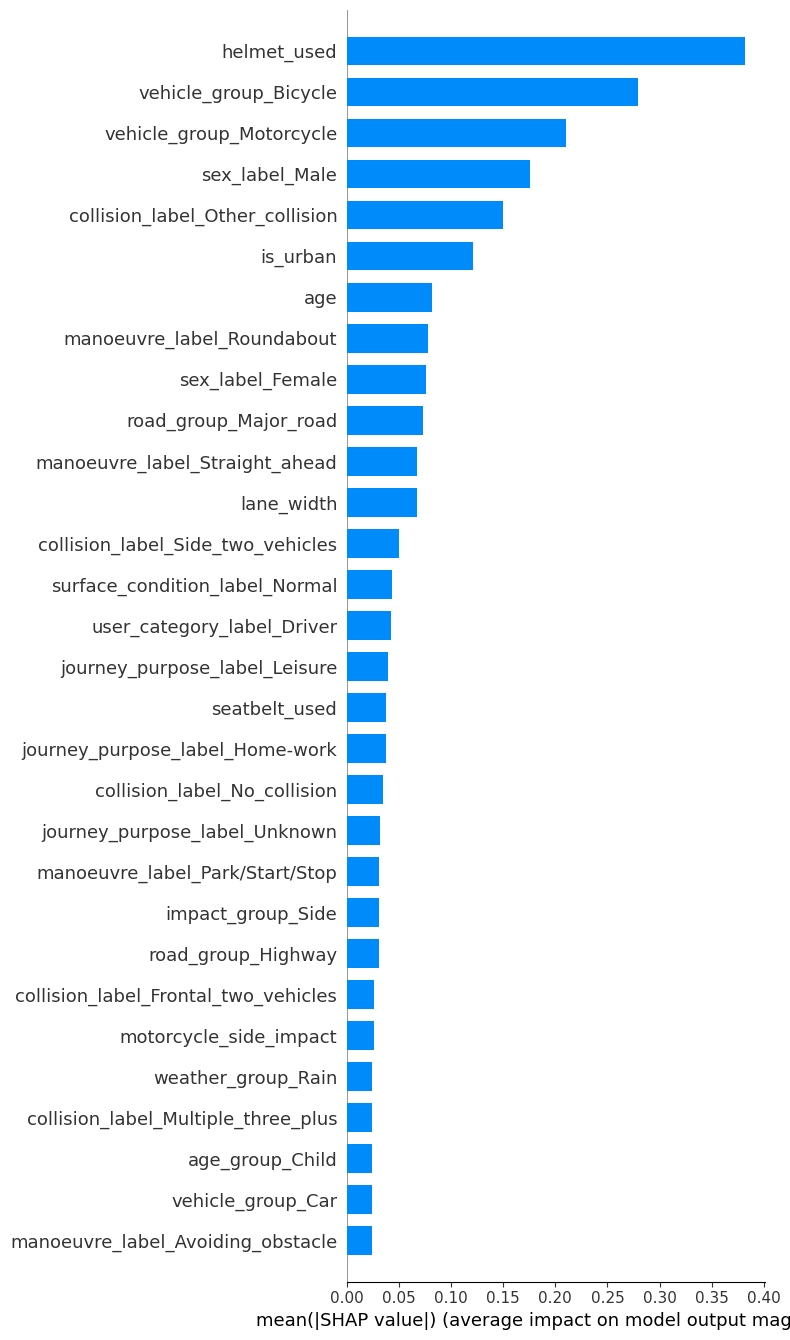

In [42]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for the trained binary model
explainer = shap.TreeExplainer(lgbm_bin, feature_perturbation="tree_path_dependent")

# Get SHAP values (binary → returns array of shape [n_samples, n_features])
shap_values = explainer.shap_values(X_test_bin)

# Global importance (bar plot)
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values, 
    X_test_bin, 
    feature_names=X_test_bin.columns, 
    plot_type="bar", 
    max_display=30, 
    show=True
)

In [43]:
### Retraining with SHAP Top Features

# Step 1: Select SHAP top features (e.g., top 40 from your summary plot)
top_shap_features = [
    "helmet_used", "vehicle_group_Bicycle", "vehicle_group_Motorcycle", "sex_label_Male",
    "collision_label_Other_collision", "is_urban", "age", "manoeuvre_label_Roundabout",
    "sex_label_Female", "road_group_Major_road", "manoeuvre_label_Straight_ahead",
    "lane_width", "collision_label_Side_two_vehicles", "surface_condition_label_Normal",
    "user_category_label_Driver", "journey_purpose_label_Leisure", "seatbelt_used",
    "journey_purpose_label_Home-work", "collision_label_No_collision",
    "journey_purpose_label_Unknown", "manoeuvre_label_Park/Start/Stop",
    "impact_group_Side", "road_group_Highway", "collision_label_Frontal_two_vehicles",
    "motorcycle_side_impact", "weather_group_Rain", "collision_label_Multiple_three_plus",
    "age_group_Child", "vehicle_group_Car", "manoeuvre_label_Avoiding_obstacle"
]

# Step 2: Prepare reduced datasets
X_train_shap = X_train_bin[top_shap_features]
X_test_shap  = X_test_bin[top_shap_features]

# Step 3: Retrain LightGBM on reduced features
lgbm_bin_shap = LGBMClassifier(
    objective='binary',
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    n_estimators=400,
    class_weight='balanced',
    random_state=42
)

lgbm_bin_shap.fit(
    X_train_shap, y_train_bin,
    eval_set=[(X_test_shap, y_test_bin)],
    eval_metric='binary_logloss',
    callbacks=[early_stopping(stopping_rounds=20)]
)

# Step 4: Evaluate
y_pred_prob = lgbm_bin_shap.predict_proba(X_test_shap)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Binary Model Performance (Severe vs Non-severe, SHAP Top Features):")
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred):.4f}")
print(f"F1 (Severe=1): {f1_score(y_test_bin, y_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_bin, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_bin, y_pred_prob):.4f}")

[LightGBM] [Info] Number of positive: 1045732, number of negative: 1045732
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.120277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 2091464, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[400]	valid_0's binary_logloss: 0.515192
Binary Model Performance (Severe vs Non-severe, SHAP Top Features):
Accuracy: 0.7445
F1 (Severe=1): 0.7504
Balanced Accuracy: 0.7454
ROC-AUC: 0.8218


In [44]:
from sklearn.metrics import classification_report

# Predictions from SHAP-retrained model
y_pred_shap = (y_pred_prob >= 0.5).astype(int)

# Classification report
report_shap = classification_report(
    y_test_bin, 
    y_pred_shap, 
    target_names=["Non-severe (0+1)", "Severe (2+3)"]
)
print(report_shap)

                  precision    recall  f1-score   support

Non-severe (0+1)       0.78      0.70      0.74    144524
    Severe (2+3)       0.72      0.79      0.75    137883

        accuracy                           0.74    282407
       macro avg       0.75      0.75      0.74    282407
    weighted avg       0.75      0.74      0.74    282407



#### Adding PCA components to your SHAP‑selected features 

In [45]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Standardize SHAP-selected features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_shap)
X_test_scaled  = scaler.transform(X_test_shap)

# Step 2: Fit PCA (choose number of components, e.g., 5)
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

# Step 3: Combine SHAP features + PCA components
import numpy as np
import pandas as pd

X_train_combined = pd.concat([
    X_train_shap.reset_index(drop=True),
    pd.DataFrame(X_train_pca, columns=[f"PCA{i+1}" for i in range(5)])
], axis=1)

X_test_combined = pd.concat([
    X_test_shap.reset_index(drop=True),
    pd.DataFrame(X_test_pca, columns=[f"PCA{i+1}" for i in range(5)])
], axis=1)

# Step 4: Retrain LightGBM with combined features
lgbm_bin_pca = LGBMClassifier(
    objective='binary',
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    n_estimators=400,
    class_weight='balanced',
    random_state=42
)

lgbm_bin_pca.fit(
    X_train_combined, y_train_bin,
    eval_set=[(X_test_combined, y_test_bin)],
    eval_metric='binary_logloss',
    callbacks=[early_stopping(stopping_rounds=20)]
)

# Step 5: Evaluate
y_pred_prob = lgbm_bin_pca.predict_proba(X_test_combined)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Binary Model Performance (Severe vs Non-severe, SHAP + PCA):")
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred):.4f}")
print(f"F1 (Severe=1): {f1_score(y_test_bin, y_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_bin, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_bin, y_pred_prob):.4f}")

Explained variance ratio: [0.12728014 0.07628697 0.06004887 0.05756219 0.05522413]
Total variance explained: 0.37640230846201594
[LightGBM] [Info] Number of positive: 1045732, number of negative: 1045732
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.125770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8925
[LightGBM] [Info] Number of data points in the train set: 2091464, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[400]	valid_0's binary_logloss: 0.515578
Binary Model Performance (Severe vs Non-severe, SHAP + PCA):
Accuracy: 0.7435
F1 (Severe=1): 0.7486
Balanced Accuracy: 0.7444
ROC-AUC: 0.8211


In [46]:
from sklearn.metrics import classification_report

# Predictions from SHAP+PCA model
y_pred_pca = (y_pred_prob >= 0.5).astype(int)

# Classification report
report_pca = classification_report(
    y_test_bin,
    y_pred_pca,
    target_names=["Non-severe (0+1)", "Severe (2+3)"]
)
print(report_pca)

                  precision    recall  f1-score   support

Non-severe (0+1)       0.77      0.71      0.74    144524
    Severe (2+3)       0.72      0.78      0.75    137883

        accuracy                           0.74    282407
       macro avg       0.75      0.74      0.74    282407
    weighted avg       0.75      0.74      0.74    282407

